# Week 4 — Noise Modelling & Higher-$p$ Analysis

**Project:** Diarka Quantum — QAOA Portfolio Optimiser  
**Goal:** Explain the noiseless→hardware gap from Week 2, not just report it.

Week 2 measured: noiseless approximation ratio **0.942** vs IBM Heron r2 **0.910** — a 3.4pp gap, plus more unique bitstrings on hardware (208→254). This notebook:

1. **Reproduces** the gap in a synthetic Heron r2 noisy simulator.
2. **Decomposes** it — turns on 1q gate → 2q gate → T1/T2 → readout one at a time and attributes the drop to each.
3. **Finds the depth crossover** — QAOA at $p=1,2,3$ noiseless vs noisy.
4. **Optionally runs $p=2$ on real hardware** to anchor the crossover with one real point.

It reuses your Week 2–3 pipeline. The only new module is `src/noise_model.py`, and `src/qaoa.py` gained backward-compatible `estimator=` / `sampler=` / `basis_gates=` hooks (every prior call still works unchanged).

In [14]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import warnings
import numpy as np
import matplotlib.pyplot as plt
from qiskit import transpile

# Silence cosmetic warnings: scipy sparse-format notices from to_matrix(),
# and Aer/qiskit deprecation chatter. These do not affect results.
warnings.filterwarnings('ignore', message='.*sparse.*')
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Your existing QAOA pipeline (now with optional noisy-primitive hooks)
from qaoa import optimise_qaoa, sample, qaoa_ansatz, approximation_ratio, ground_state_probability

# New Week 4 module
from noise_model import (
    HeronParams, NoiseChannels, synthetic_heron_noise_model,
    noisy_estimator, noisy_sampler, attribution_suite,
    noise_model_from_backend, HERON_BASIS_GATES,
)

RNG_SEED = 42
SHOTS = 8192   # more shots tightens the sampled-counts energy estimate
np.random.seed(RNG_SEED)
os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)
print('Imports OK')

Imports OK


## 1. Reload the Week 2 baseline Hamiltonian

We reload the cached `hamiltonian.npz` (the exact operator that produced the 0.942 simulator / 0.910 hardware ratios) rather than re-fetching prices — same pattern as `06_robustness_and_sensitivity.ipynb`. Baseline parameters: risk-aversion `q = 0.5`, budget `k = 4` of 8 FTSE assets, ground state `00001111`.

In [15]:
from pathlib import Path
from qiskit.quantum_info import SparsePauliOp

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PROCESSED = ROOT / 'data' / 'processed'

ham_data = np.load(DATA_PROCESSED / 'hamiltonian.npz', allow_pickle=False)
ising = SparsePauliOp.from_list(
    [(str(l), float(c)) for l, c in zip(ham_data['pauli_labels'], ham_data['pauli_coeffs'])]
)
ISING_OFFSET = float(ham_data['ising_offset'])
E_GROUND     = float(ham_data['ground_energy'])    # baseline reference (-1.4436)
GROUND_BITS  = str(ham_data['ground_bitstring'])   # '00001111'
TICKERS      = tuple(str(t) for t in ham_data['tickers'])

# Hard-coded baseline parameters (identical to Week 2 headline run)
RISK_FACTOR = 0.5
BUDGET      = 4

n_qubits = ising.num_qubits
print(f'Hamiltonian on {n_qubits} qubits, {len(ising)} Pauli terms')
print(f'Tickers: {TICKERS}')
print(f'Baseline ground bitstring (loaded): {GROUND_BITS}  ->', 
      [TICKERS[i] for i, b in enumerate(reversed(GROUND_BITS)) if b == "1"])

Hamiltonian on 8 qubits, 36 Pauli terms
Tickers: ('HSBA.L', 'AZN.L', 'SHEL.L', 'ULVR.L', 'RIO.L', 'BT-A.L', 'VOD.L', 'DGE.L')
Baseline ground bitstring (loaded): 00001111  -> ['HSBA.L', 'AZN.L', 'SHEL.L', 'ULVR.L']


In [16]:
# Spectrum bounds + ground bitstring, derived directly from `ising`.
# The QAOA cost Hamiltonian is DIAGONAL (only I/Z terms), so every eigenstate
# is a computational basis state and we can read the spectrum off the diagonal
# without depending on any external eigensolver helper.
diag = np.real(np.diag(ising.to_matrix()))
ground_energy = float(diag.min())
max_energy = float(diag.max())
ground_idx = int(np.argmin(diag))
# Qiskit measure_all keys are q_{n-1}...q_0 (qubit 0 is the LSB), which is exactly
# the binary expansion of the matrix index. So this string matches counts keys.
ground_bitstring = format(ground_idx, f'0{n_qubits}b')
print(f'Ground energy: {ground_energy:.4f}  bitstring: {ground_bitstring}')
print(f'Max energy:    {max_energy:.4f}')

# Cross-check against the cached baseline. The approximation ratio is invariant
# to the constant ising_offset (it cancels), so we compare in the SAME convention
# as optimise_qaoa returns (<H> without offset). The bitstring must match exactly.
assert ground_bitstring == GROUND_BITS, (
    f'Ground bitstring mismatch: computed {ground_bitstring} vs loaded {GROUND_BITS}. '
    'Check bit ordering before trusting P(GS).')
print(f'Cross-check OK: computed ground bitstring matches loaded baseline ({GROUND_BITS}).')
print(f'(Loaded E_GROUND={E_GROUND:.4f} is the offset-inclusive objective; '
      f'ratio uses the <H> convention and is offset-invariant.)')

# --- Sampled-energy machinery (matches how HARDWARE is measured) ---
# On real hardware you never get <H> directly; you get shots and estimate the
# energy from the measured bitstring distribution. To compare like-for-like,
# the noisy-simulator runs below do the same. This also captures READOUT error,
# which a statevector/Aer estimator's <H> does not see.
idx2e = {format(i, f'0{n_qubits}b'): float(diag[i]) for i in range(2**n_qubits)}

def energy_from_counts(counts):
    """Estimate <H> from a measured bitstring distribution (hardware-style)."""
    total = sum(counts.values())
    return sum(idx2e[b] * c for b, c in counts.items()) / total

def noisy_sampled_counts(p, angles, noise_model, shots=SHOTS, seed=RNG_SEED):
    """Build QAOA(p), transpile to native gates, bind fixed angles, sample under noise.
    Returns the measured counts. No optimiser is invoked (true fixed-angle eval),
    so there is no COBYLA maxfun warning and the angles are exactly `angles`."""
    anz = transpile(qaoa_ansatz(ising, p), basis_gates=HERON_BASIS_GATES, optimization_level=1)
    anz.measure_all()
    samp = noisy_sampler(noise_model, seed=seed)
    return samp.run([(anz, angles)], shots=shots).result()[0].data.meas.get_counts()

Ground energy: -1.4436  bitstring: 00001111
Max energy:    8.1419
Cross-check OK: computed ground bitstring matches loaded baseline (00001111).
(Loaded E_GROUND=-1.4436 is the offset-inclusive objective; ratio uses the <H> convention and is offset-invariant.)


## 2. Noiseless baseline (statevector, your default path)

In [17]:
res_ideal = optimise_qaoa(ising, p=1)                     # default StatevectorEstimator
res_ideal = sample(res_ideal, shots=SHOTS, seed=RNG_SEED) # default StatevectorSampler

r_ideal = approximation_ratio(res_ideal.optimal_energy,
                              ground_energy=ground_energy, max_energy=max_energy)
pgs_ideal = ground_state_probability(res_ideal.counts, ground_bitstring, res_ideal.shots)
print(f'noiseless: ratio={r_ideal:.4f}  P(GS)={pgs_ideal*100:.3f}%  unique={len(res_ideal.counts)}')

/opt/anaconda3/envs/qiskit-env/lib/python3.13/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/opt/anaconda3/envs/qiskit-env/lib/python3.13/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


noiseless: ratio=0.9417  P(GS)=0.745%  unique=218


## 3. Reproduce the gap (full synthetic Heron r2 noise at $p=1$)

We run the noiseless-optimal angles under noise and estimate the energy from the **sampled bitstrings** — exactly how the Week 2 hardware ratio (0.910) was measured. This captures readout error and finite-sampling effects that an estimator's ⟨H⟩ cannot see. Target: noisy ratio near the measured **0.910**.

In [18]:
nm_full = synthetic_heron_noise_model(n_qubits=n_qubits)
print('Noise registered for:', sorted(nm_full.noise_instructions))

# Sample the noiseless-optimal angles under full noise; estimate energy from counts.
counts_noisy = noisy_sampled_counts(1, res_ideal.optimal_params, nm_full)
e_noisy = energy_from_counts(counts_noisy)
r_noisy = approximation_ratio(e_noisy, ground_energy=ground_energy, max_energy=max_energy)
pgs_noisy = ground_state_probability(counts_noisy, ground_bitstring, sum(counts_noisy.values()))
cz_count = transpile(qaoa_ansatz(ising, 1), basis_gates=HERON_BASIS_GATES,
                     optimization_level=1).count_ops().get('cz', 0)

print(f'noiseless: ratio={r_ideal:.4f}  P(GS)={pgs_ideal*100:.3f}%  unique={len(res_ideal.counts)}')
print(f'noisy:     ratio={r_noisy:.4f}  P(GS)={pgs_noisy*100:.3f}%  unique={len(counts_noisy)}')
print(f'CZ gates in transpiled p=1 circuit: {cz_count}')
print(f'simulated gap: {(r_ideal - r_noisy)*100:.2f} pp   (measured hardware gap was 3.40 pp)')

Noise registered for: ['cx', 'cz', 'ecr', 'id', 'measure', 'sx', 'x']
noiseless: ratio=0.9417  P(GS)=0.745%  unique=218
noisy:     ratio=0.9339  P(GS)=0.696%  unique=253
CZ gates in transpiled p=1 circuit: 56
simulated gap: 0.78 pp   (measured hardware gap was 3.40 pp)


If the simulated gap is far from 3.4pp, tune `HeronParams` in `src/noise_model.py` — most sensitive knobs are `two_qubit_gate_error` and `readout_error` — and re-run. Matching the measured gap is itself a credible, quotable result.

## 4. Noise decomposition — the headline plot

Accumulate channels one at a time. The drop introduced at each step is that channel's contribution to the total gap.

In [19]:
labels, ratios = [], []
for name, ch in attribution_suite().items():
    nm = synthetic_heron_noise_model(channels=ch, n_qubits=n_qubits)
    counts = noisy_sampled_counts(1, res_ideal.optimal_params, nm)
    r = approximation_ratio(energy_from_counts(counts),
                            ground_energy=ground_energy, max_energy=max_energy)
    labels.append(name); ratios.append(r)
    print(f'{name:18s} ratio={r:.4f}')

# Each channel's contribution = the drop it introduces when switched on.
# Sampled-counts ratios carry shot noise (~1/sqrt(shots)); with 8192 shots a
# contribution below ~0.05 pp is at the noise floor and not meaningful.
contributions = [ratios[i-1] - ratios[i] for i in range(1, len(ratios))]
contrib_labels = labels[1:]

ideal              ratio=0.9418
+1q gate           ratio=0.9414
+2q gate           ratio=0.9387
+T1/T2             ratio=0.9381
+readout (full)    ratio=0.9339


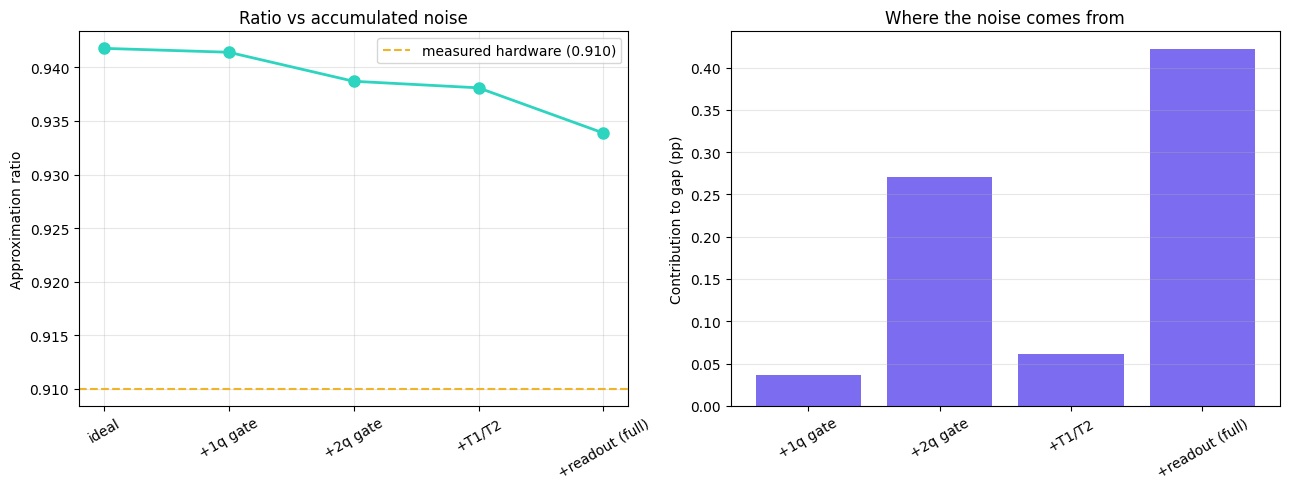

Saved figures/week4_noise_decomposition.png


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(labels, ratios, 'o-', color='#2dd4bf', lw=2, ms=8)
ax1.axhline(0.910, ls='--', color='#f0b429', label='measured hardware (0.910)')
ax1.set_ylabel('Approximation ratio'); ax1.set_title('Ratio vs accumulated noise')
ax1.tick_params(axis='x', rotation=30); ax1.legend(); ax1.grid(alpha=0.3)

ax2.bar(contrib_labels, [c*100 for c in contributions], color='#7c6cf0')
ax2.set_ylabel('Contribution to gap (pp)'); ax2.set_title('Where the noise comes from')
ax2.tick_params(axis='x', rotation=30); ax2.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../figures/week4_noise_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/week4_noise_decomposition.png')

## 5. Depth crossover — $p=1,2,3$ noiseless vs noisy

Noiselessly, more layers help monotonically. Under noise, each layer roughly doubles the CZ count, so noise eventually wins. The crossover is the core Week 4 physics insight.

In [21]:
p_values = [1, 2, 3]
ideal_by_p, noisy_by_p, cz_by_p = [], [], []

for p in p_values:
    ri = optimise_qaoa(ising, p=p)                       # full noiseless optimisation
    r_i = approximation_ratio(ri.optimal_energy, ground_energy=ground_energy, max_energy=max_energy)

    # Noisy: sample the noiseless-optimal angles under noise, energy from counts.
    nm_p = synthetic_heron_noise_model(n_qubits=n_qubits)
    counts_p = noisy_sampled_counts(p, ri.optimal_params, nm_p)
    r_n = approximation_ratio(energy_from_counts(counts_p),
                              ground_energy=ground_energy, max_energy=max_energy)
    cz_p = transpile(qaoa_ansatz(ising, p), basis_gates=HERON_BASIS_GATES,
                     optimization_level=1).count_ops().get('cz', 0)

    ideal_by_p.append(r_i); noisy_by_p.append(r_n); cz_by_p.append(cz_p)
    print(f'p={p}: noiseless={r_i:.4f}  noisy={r_n:.4f}  (CZ={cz_p})')

p=1: noiseless=0.9417  noisy=0.9339  (CZ=56)
p=2: noiseless=0.9437  noisy=0.9323  (CZ=112)
p=3: noiseless=0.9530  noisy=0.9321  (CZ=168)


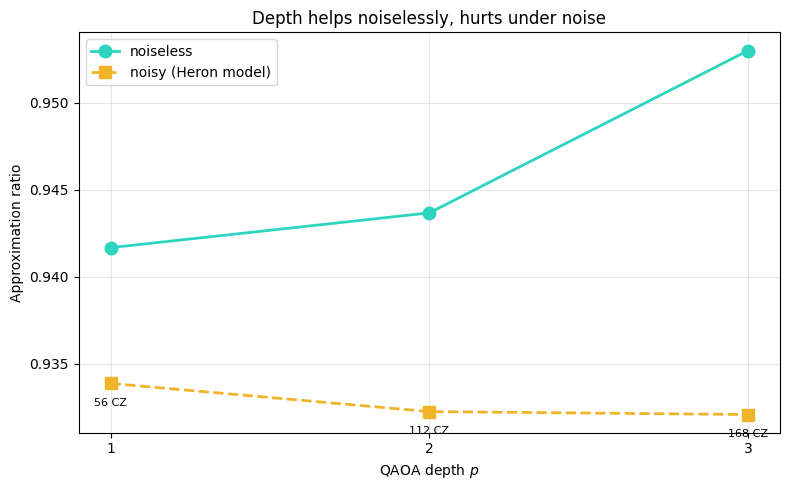

Saved figures/week4_depth_crossover.png


In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_values, ideal_by_p, 'o-', color='#2dd4bf', lw=2, ms=9, label='noiseless')
ax.plot(p_values, noisy_by_p, 's--', color='#f0b429', lw=2, ms=9, label='noisy (Heron model)')
for p, r, cz in zip(p_values, noisy_by_p, cz_by_p):
    ax.annotate(f'{cz} CZ', (p, r), textcoords='offset points', xytext=(0, -16), fontsize=8, ha='center')
ax.set_xlabel('QAOA depth $p$'); ax.set_ylabel('Approximation ratio')
ax.set_title('Depth helps noiselessly, hurts under noise')
ax.set_xticks(p_values); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/week4_depth_crossover.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/week4_depth_crossover.png')

## 6. Hardware run at $p=2$ (spends IBM Quantum quota)

**Leave `RUN_HARDWARE = False` until everything above runs.** This submits ONE $p=2$ job at the noiseless-optimal angles — do not re-optimise on hardware. For the noisy-simulator transpile we use `basis_gates`; for real hardware we transpile against the backend so the layout/coupling map is respected.

In [23]:
RUN_HARDWARE = False

if RUN_HARDWARE:
    from qiskit import transpile
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
    from qaoa import qaoa_ansatz

    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=n_qubits)
    print('Backend:', backend.name)

    # Noiseless-optimal p=2 angles
    ri_p2 = optimise_qaoa(ising, p=2)

    # Transpile against the REAL backend (respects coupling map + native gates)
    ansatz = qaoa_ansatz(ising, p=2)
    ansatz.measure_all()
    isa = transpile(ansatz, backend=backend, optimization_level=3)
    bound = isa.assign_parameters(ri_p2.optimal_params)

    sampler = RuntimeSampler(mode=backend)
    job = sampler.run([bound], shots=SHOTS)
    print('Job ID:', job.job_id(), '— save this for your portfolio log')
    counts = job.result()[0].data.meas.get_counts()

    # Energy from measured distribution (diagonal H lookup over the sample)
    idx = {format(i, f'0{n_qubits}b'): diag[i] for i in range(2**n_qubits)}
    e_hw = sum(idx[b]*c for b, c in counts.items()) / sum(counts.values())
    r_hw_p2 = approximation_ratio(e_hw, ground_energy=ground_energy, max_energy=max_energy)
    pgs_hw = ground_state_probability(counts, ground_bitstring, sum(counts.values()))
    print(f'HARDWARE p=2: ratio={r_hw_p2:.4f}  P(GS)={pgs_hw*100:.3f}%  unique={len(counts)}')
else:
    print('Hardware run skipped. Set RUN_HARDWARE = True when ready.')

Hardware run skipped. Set RUN_HARDWARE = True when ready.


## 7. Persist results for the writeup

In [24]:
import json
summary = {
    'p1_ratio_ideal': float(r_ideal),
    'p1_ratio_noisy': float(r_noisy),
    'p1_pgs_ideal': float(pgs_ideal),
    'p1_pgs_noisy': float(pgs_noisy),
    'simulated_gap_pp': float((r_ideal - r_noisy) * 100),
    'cz_count_p1': int(cz_count),
    'decomposition_pp': {contrib_labels[i]: float(contributions[i]*100) for i in range(len(contributions))},
    'ideal_by_p': {str(p): float(v) for p, v in zip(p_values, ideal_by_p)},
    'noisy_by_p': {str(p): float(v) for p, v in zip(p_values, noisy_by_p)},
    'cz_by_p': {str(p): int(v) for p, v in zip(p_values, cz_by_p)},
}
with open('../results/week4_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

{
  "p1_ratio_ideal": 0.9416724406769403,
  "p1_ratio_noisy": 0.9338730403048103,
  "p1_pgs_ideal": 0.0074462890625,
  "p1_pgs_noisy": 0.0069580078125,
  "simulated_gap_pp": 0.7799400372130005,
  "cz_count_p1": 56,
  "decomposition_pp": {
    "+1q gate": 0.03632965459811066,
    "+2q gate": 0.27080676028812256,
    "+T1/T2": 0.061357485878277274,
    "+readout (full)": 0.4217877710783302
  },
  "ideal_by_p": {
    "1": 0.9416724406769403,
    "2": 0.9436704068695195,
    "3": 0.952994410671263
  },
  "noisy_by_p": {
    "1": 0.9338730403048103,
    "2": 0.9322556259123299,
    "3": 0.9320876490838663
  },
  "cz_by_p": {
    "1": 56,
    "2": 112,
    "3": 168
  }
}
